# ¿Sembrar árboles o cuidar los que ya están? En la Amazonía, restaurar rinde una cuarta parte

En 6.900 fincas de la frontera de deforestación de la Amazonía brasileña, evitar que el bosque en pie sea talado o quemado aporta 2,28 veces la biodiversidad que aporta evitar la deforestación. Y restaurar lo perdido rinde 0,26 veces lo que rinde evitar deforestar. Son cifras de un modelo contrafactual, no de un experimento — pero el ranking se sostiene incluso recortando los costos de restaurar un 95 %.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Miranda et al. (2026). *Protecting tropical forests is more cost-effective for biodiversity and climate than restoration*. **Science** 393(6817).
DOI: [10.1126/science.adx9928](https://doi.org/10.1126/science.adx9928) · acceso abierto

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-17-proteger-bosques-tropicales-vs-restaurar/notebook.ipynb)

**Video:** pendiente

## De qué va esto

Frenar la deforestación y restaurar bosque son las dos grandes apuestas contra la crisis climática y de biodiversidad en los trópicos. Hay una tercera que recibe mucha menos atención: evitar la *perturbación* — que un bosque que sigue en pie sea talado selectivamente o quemado. Un equipo de investigadores brasileños y británicos comparó las tres en dos regiones de Pará, Brasil (Santarém y Paragominas), más de 3 millones de hectáreas donde la frontera agrícola lleva décadas avanzando.

Cómo lo hicieron: en 2010 midieron aves, árboles y carbono en 381 transectos de campo (franjas de muestreo) repartidos en 38 cuencas; con eso entrenaron modelos (*random forest*) que predicen dónde vive cada especie y cuánto carbono guarda cada píxel. Luego construyeron cuatro escenarios para 2010-2020: lo que pasó de verdad (*business as usual*) y tres contrafactuales — sin deforestación, sin perturbación, con restauración del bosque que la ley exige. El "beneficio" de cada intervención es la diferencia entre su escenario y el real. No hay manipulación experimental: son diferencias modeladas, y los propios autores insisten en que los escenarios son herramientas de diagnóstico, no predicciones literales.

Lo que tenemos en abierto (Zenodo): los beneficios de cada intervención sumados dentro de cada una de las 6.900 propiedades rurales registradas en el catastro ambiental (CAR), el carbono medido en 375 transectos con dato, y la tabla de especies modeladas. Con eso replicamos la figura central del paper. Veamos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
BIN_PP = 5                              # ancho del bin de cobertura forestal (puntos porcentuales) para las curvas
CLASES_CURVAS = ['mediana', 'grande']   # el paper dibuja la Fig 3 solo con fincas medianas y grandes
REGION = None                           # None = ambas · 'Santarem' · 'Paragominas'
UMBRAL_LEGAL_PCT = 80                   # Reserva Legal del bioma Amazonia: 80 % de la finca con bosque (aproximación)
FUENTE = 'Fuente: Miranda et al. (2026), Science | Datos: Zenodo 10.5281/zenodo.19221348'
COLOR_ADEF = '#2563EB'    # evitar deforestación
COLOR_ADEG = '#059669'    # evitar perturbación (tala selectiva / fuego)
COLOR_REST = '#D97706'    # restauración
COLOR_ALERTA = '#DC2626'
COLOR_GRIS = '#BBBBBB'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
os.makedirs('datos', exist_ok=True); os.makedirs('figuras', exist_ok=True)
for f in ['propiedades_beneficios.csv', 'carbono_transectos.csv', 'especies_modelos.csv']:
    if not os.path.exists(f'datos/{f}'):
        urllib.request.urlretrieve(f'{BASE}/papers/2026-09-17-proteger-bosques-tropicales-vs-restaurar/datos/{f}', f'datos/{f}')

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

prop = pd.read_csv('datos/propiedades_beneficios.csv')
carb = pd.read_csv('datos/carbono_transectos.csv')
esp = pd.read_csv('datos/especies_modelos.csv')

INTER = ['evitar_deforestacion', 'evitar_perturbacion', 'restauracion']
NOMBRE = {'evitar_deforestacion': 'Evitar deforestación', 'evitar_perturbacion': 'Evitar perturbación', 'restauracion': 'Restauración'}
COLOR = {'evitar_deforestacion': COLOR_ADEF, 'evitar_perturbacion': COLOR_ADEG, 'restauracion': COLOR_REST}

def es(x, dec=0):
    # formato español: miles con punto, decimales con coma
    s = f'{x:,.{dec}f}'
    return s.replace(',', 'X').replace('.', ',').replace('X', '.')

print(f'Propiedades CAR: {es(len(prop))}  ({es((prop.region=="Santarem").sum())} Santarém + {es((prop.region=="Paragominas").sum())} Paragominas)')
print(f'  por clase: {prop.clase_tamano.value_counts().to_dict()}')
print(f'  área total: {es(prop.area_ha.sum())} ha · mediana {es(prop.area_ha.median(), 1)} ha')
print(f'Transectos con dato de carbono: {len(carb)} en {carb.cuenca.nunique()} cuencas')
print(f'Especies en la tabla: {len(esp)} · modeladas (SDM): {es((esp.metodo=="SDM").sum())} '
      f'({(esp[esp.metodo=="SDM"].grupo=="aves").sum()} aves + {(esp[esp.metodo=="SDM"].grupo=="arboles").sum()} árboles) · '
      f'AUC mínimo {esp.auc.min():.2f}, mediana {es(esp.auc.median(), 3)}')

Propiedades CAR: 6.900  (5.361 Santarém + 1.539 Paragominas)
  por clase: {'pequena': 5868, 'grande': 600, 'mediana': 432}
  área total: 2.623.360 ha · mediana 58,9 ha
Transectos con dato de carbono: 375 en 38 cuencas
Especies en la tabla: 1151 · modeladas (SDM): 586 (160 aves + 426 árboles) · AUC mínimo 0.80, mediana 0,988


## Aquí está.

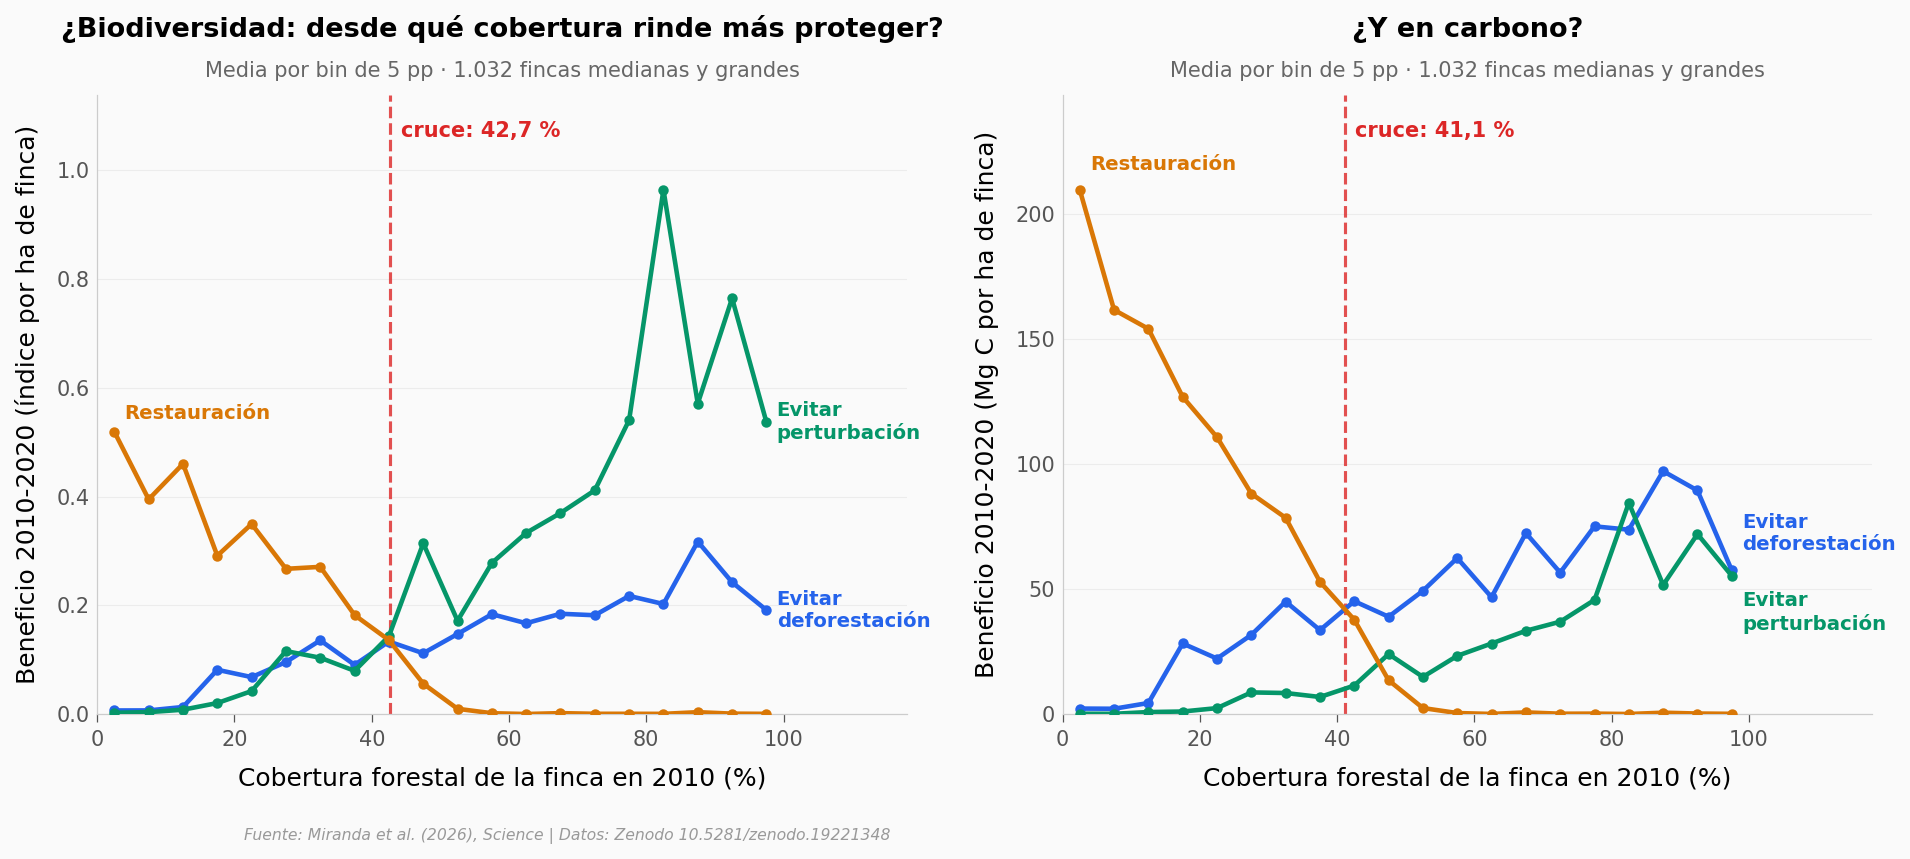

Cruce restauración < evitar deforestación — biodiversidad: 42,7 % · carbono: 41,1 % de cobertura 2010
Cruce restauración < evitar perturbación — biodiversidad: 42,2 % · carbono: 46,1 %
Fincas por bin: mínimo 15 (bin [15, 20)) · máximo 174 (bin [95, 100)) · bins con menos de 30: 5 de 20


In [2]:
# Réplica de la Fig 3 del paper: beneficio por hectárea de finca (2010-2020) según cuánto bosque tenía la finca en 2010.
# Media por bin de cobertura, solo fincas medianas y grandes (las únicas con obligación legal de restaurar).
ml = prop[prop.clase_tamano.isin(CLASES_CURVAS)].copy()
if REGION:
    ml = ml[ml.region == REGION]
bins = np.arange(0, 100 + BIN_PP, BIN_PP)
ml['bin'] = pd.cut(ml.cobertura_forestal_2010_pct, bins, right=False, include_lowest=True)

def curvas(df, prefijo, sufijo):
    g = df.groupby('bin', observed=True)[[f'{prefijo}_{i}{sufijo}' for i in INTER]].mean()
    g.columns = INTER
    g['n'] = df.groupby('bin', observed=True).size()
    g['centro'] = [b.left + BIN_PP / 2 for b in g.index]
    return g

def cruce(g, a='restauracion', b='evitar_deforestacion'):
    # primer bin (de menos a más bosque) donde a deja de superar a b, interpolación lineal
    d = (g[a] - g[b]).values; x = g['centro'].values
    for k in range(len(d) - 1):
        if d[k] > 0 and d[k + 1] <= 0:
            return x[k] + (x[k + 1] - x[k]) * d[k] / (d[k] - d[k + 1])
    return None

g_bio = curvas(ml, 'biodiv', '_por_ha')
g_car = curvas(ml, 'carbono', '_mgc_por_ha')
x_bio, x_car = cruce(g_bio), cruce(g_car)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, g, xc, titulo, ylab in [
        (axes[0], g_bio, x_bio, '¿Biodiversidad: desde qué cobertura rinde más proteger?', 'Beneficio 2010-2020 (índice por ha de finca)'),
        (axes[1], g_car, x_car, '¿Y en carbono?', 'Beneficio 2010-2020 (Mg C por ha de finca)')]:
    for i in INTER:
        ax.plot(g['centro'], g[i], color=COLOR[i], linewidth=2.2, marker='o', markersize=4, zorder=5)
    ymax = g[INTER].values.max()
    ax.set_ylim(0, ymax * 1.18)
    if xc is not None:
        ax.axvline(xc, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.8)
        ax.text(xc + 1.5, ymax * 1.1, f'cruce: {es(xc, 1)} %', color=COLOR_ALERTA, fontsize=10, fontweight='bold')
    # etiquetas inline — si las dos curvas de "evitar" terminan casi juntas, separar las etiquetas
    ax.text(4, g['restauracion'].iloc[0] * 1.03, 'Restauración', color=COLOR_REST, fontsize=9.5, fontweight='bold', va='bottom')
    y_adeg, y_adef = g['evitar_perturbacion'].iloc[-1], g['evitar_deforestacion'].iloc[-1]
    if abs(y_adeg - y_adef) < 0.12 * ymax:
        y_adef, y_adeg = max(y_adef, y_adeg) + 0.07 * ymax, min(y_adef, y_adeg) - 0.07 * ymax
    ax.text(99, y_adeg, 'Evitar\nperturbación', color=COLOR_ADEG, fontsize=9.5, fontweight='bold', va='center')
    ax.text(99, y_adef, 'Evitar\ndeforestación', color=COLOR_ADEF, fontsize=9.5, fontweight='bold', va='center')
    ax.set_xlim(0, 118)
    ax.set_xlabel('Cobertura forestal de la finca en 2010 (%)')
    ax.set_ylabel(ylab)
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=28)
    ax.text(0.5, 1.03, f'Media por bin de {BIN_PP} pp · {es(len(ml))} fincas medianas y grandes', transform=ax.transAxes,
            fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/fig3_cruce.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Cruce restauración < evitar deforestación — biodiversidad: {es(x_bio, 1)} % · carbono: {es(x_car, 1)} % de cobertura 2010')
print(f'Cruce restauración < evitar perturbación — biodiversidad: {es(cruce(g_bio, b="evitar_perturbacion"), 1)} % · carbono: {es(cruce(g_car, b="evitar_perturbacion"), 1)} %')
print(f'Fincas por bin: mínimo {g_car.n.min()} (bin {g_car.n.idxmin()}) · máximo {g_car.n.max()} (bin {g_car.n.idxmax()}) · bins con menos de 30: {(g_car.n < 30).sum()} de {len(g_car)}')

## Lo que dice la curva

Restaurar gana solo en las fincas que ya casi no tienen bosque. En una finca con menos del 20 % de cobertura no queda mucho que proteger — la restauración es lo único que puede sumar, y en carbono suma mucho: 210 toneladas de carbono (Mg C) por hectárea de finca en el tramo (bin) de 0-5 %, frente a 2,3 de evitar deforestación. Pero a medida que la finca conserva más bosque, la restauración cae hasta casi cero (0,16 Mg C/ha en el bin 95-100 %) y proteger despega: evitar deforestación llega a 97,1 Mg C/ha en el bin 85-90 % y evitar perturbación a 84,4 en el 80-85 %.

El punto donde se cruzan es el dato: 42,7 % de cobertura para biodiversidad y 41,1 % para carbono. El paper reporta ~43 % y ~41 % con un método distinto (un modelo aditivo con 1.000 remuestreos); nosotros usamos la media por bin de 5 puntos y una interpolación lineal, y el cruce cae en el mismo sitio. Con bins de 10 puntos sale 43,1 % y 41,0 %. Esa es la verificación fuerte de este notebook: dos métodos distintos, el mismo cruce.

Ojo con la izquierda de la gráfica: cinco de los seis bins entre 5 % y 35 % tienen menos de 30 fincas (el mínimo es 15, en 15-20 %), así que esas medias son ruidosas. La parte derecha, donde proteger gana, está mucho mejor poblada: 174 fincas en el bin 95-100 %. Otras 25 fincas medianas y grandes tienen una cobertura registrada de 100 % o más — un artefacto de contar el bosque en píxeles sobre el polígono de la finca — y quedan fuera de las curvas, igual que en la figura del paper.

Y una cosa que la gráfica no dice sola: el eje Y es beneficio por hectárea *de toda la finca* en diez años, no por hectárea intervenida ni por año. Por eso estas cifras no son comparables con la Fig 2 del paper, que mide el beneficio por píxel intervenido y por año.

## ¿Y sumando las 6.900 fincas?

La curva compara fincas parecidas. ¿Y si sumamos el beneficio de cada intervención sobre todas las propiedades del catastro, sin distinguirlas?

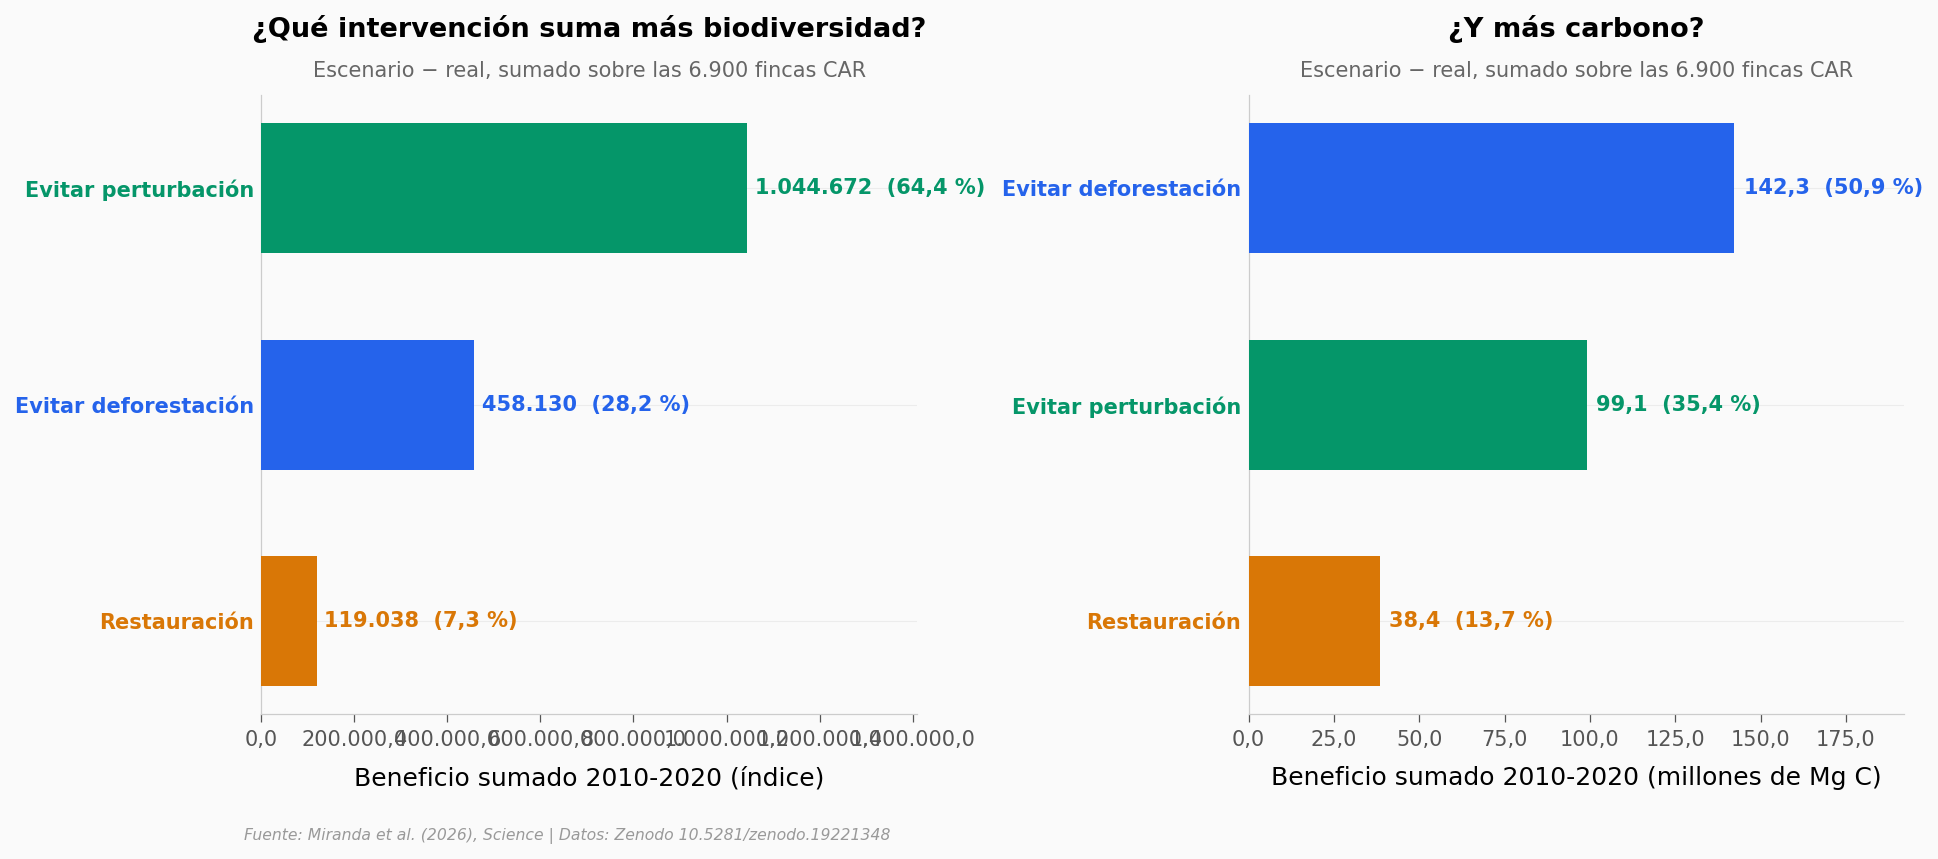

Biodiversidad — evitar perturbación / evitar deforestación: 2,28×  (paper, paisaje completo: 2,45×)
Carbono       — evitar deforestación / evitar perturbación: 1,44×  (paper: 1,30×)
Restauración / evitar deforestación — biodiversidad: 0,26×  · carbono: 0,27×  (paper: 0,23× / 0,24×)


In [3]:
sum_bio = {i: prop[f'biodiv_{i}'].sum() for i in INTER}
sum_car = {i: prop[f'carbono_{i}_mgc'].sum() / 1e6 for i in INTER}   # millones de Mg C

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, vals, titulo, unidad, dec in [
        (axes[0], sum_bio, '¿Qué intervención suma más biodiversidad?', 'índice', 0),
        (axes[1], sum_car, '¿Y más carbono?', 'millones de Mg C', 1)]:
    orden = sorted(INTER, key=lambda i: vals[i])
    y = np.arange(len(orden))
    total = sum(vals.values())
    ax.barh(y, [vals[i] for i in orden], color=[COLOR[i] for i in orden], height=0.6, zorder=5)
    for k, i in enumerate(orden):
        ax.text(vals[i] + total * 0.01, k, f'{es(vals[i], dec)}  ({es(100 * vals[i] / total, 1)} %)', va='center', fontsize=10, fontweight='bold', color=COLOR[i])
    ax.set_yticks(y); ax.set_yticklabels([NOMBRE[i] for i in orden], fontsize=10, fontweight='bold')
    for tick, i in zip(ax.get_yticklabels(), orden):
        tick.set_color(COLOR[i])
    ax.set_xlim(0, max(vals.values()) * 1.35)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: es(v, dec)))
    ax.set_xlabel(f'Beneficio sumado 2010-2020 ({unidad})')
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=28)
    ax.text(0.5, 1.03, 'Escenario − real, sumado sobre las 6.900 fincas CAR', transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/beneficio_sumado.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Biodiversidad — evitar perturbación / evitar deforestación: {es(sum_bio["evitar_perturbacion"] / sum_bio["evitar_deforestacion"], 2)}×  (paper, paisaje completo: 2,45×)')
print(f'Carbono       — evitar deforestación / evitar perturbación: {es(sum_car["evitar_deforestacion"] / sum_car["evitar_perturbacion"], 2)}×  (paper: 1,30×)')
print(f'Restauración / evitar deforestación — biodiversidad: {es(sum_bio["restauracion"] / sum_bio["evitar_deforestacion"], 2)}×  · carbono: {es(sum_car["restauracion"] / sum_car["evitar_deforestacion"], 2)}×  (paper: 0,23× / 0,24×)')

## Dos rankings distintos

En biodiversidad, evitar la perturbación aporta 2,28 veces lo que aporta evitar la deforestación: 64,4 % del beneficio sumado frente a 28,2 %. En carbono se invierte: evitar deforestación rinde 1,44 veces lo de evitar perturbación (50,9 % frente a 35,4 %). La restauración queda última en ambos: 7,3 % del beneficio en biodiversidad y 13,7 % en carbono — 0,26 y 0,27 veces lo que rinde evitar deforestar.

El paper da ratios algo distintos (2,45×, 1,30×, 0,23× y 0,24×) porque suma todo el paisaje, más de 3 millones de hectáreas que incluyen tierras públicas y la Floresta Nacional do Tapajós; nosotros solo tenemos las 2.623.360 ha de las fincas registradas. La diferencia es del 7 al 13 %, y el orden no cambia.

¿Por qué la perturbación pesa tanto en biodiversidad? Una pista está en la superficie: entre 2010 y 2020 se deforestaron 158.980 ha en estas dos regiones, pero se talaron selectivamente o quemaron 273.558 ha de bosque primario — casi el doble de superficie. Y un bosque perturbado sigue siendo bosque para muchas especies, pero no guarda el mismo carbono. Eso lo podemos ver directamente en los transectos de campo.

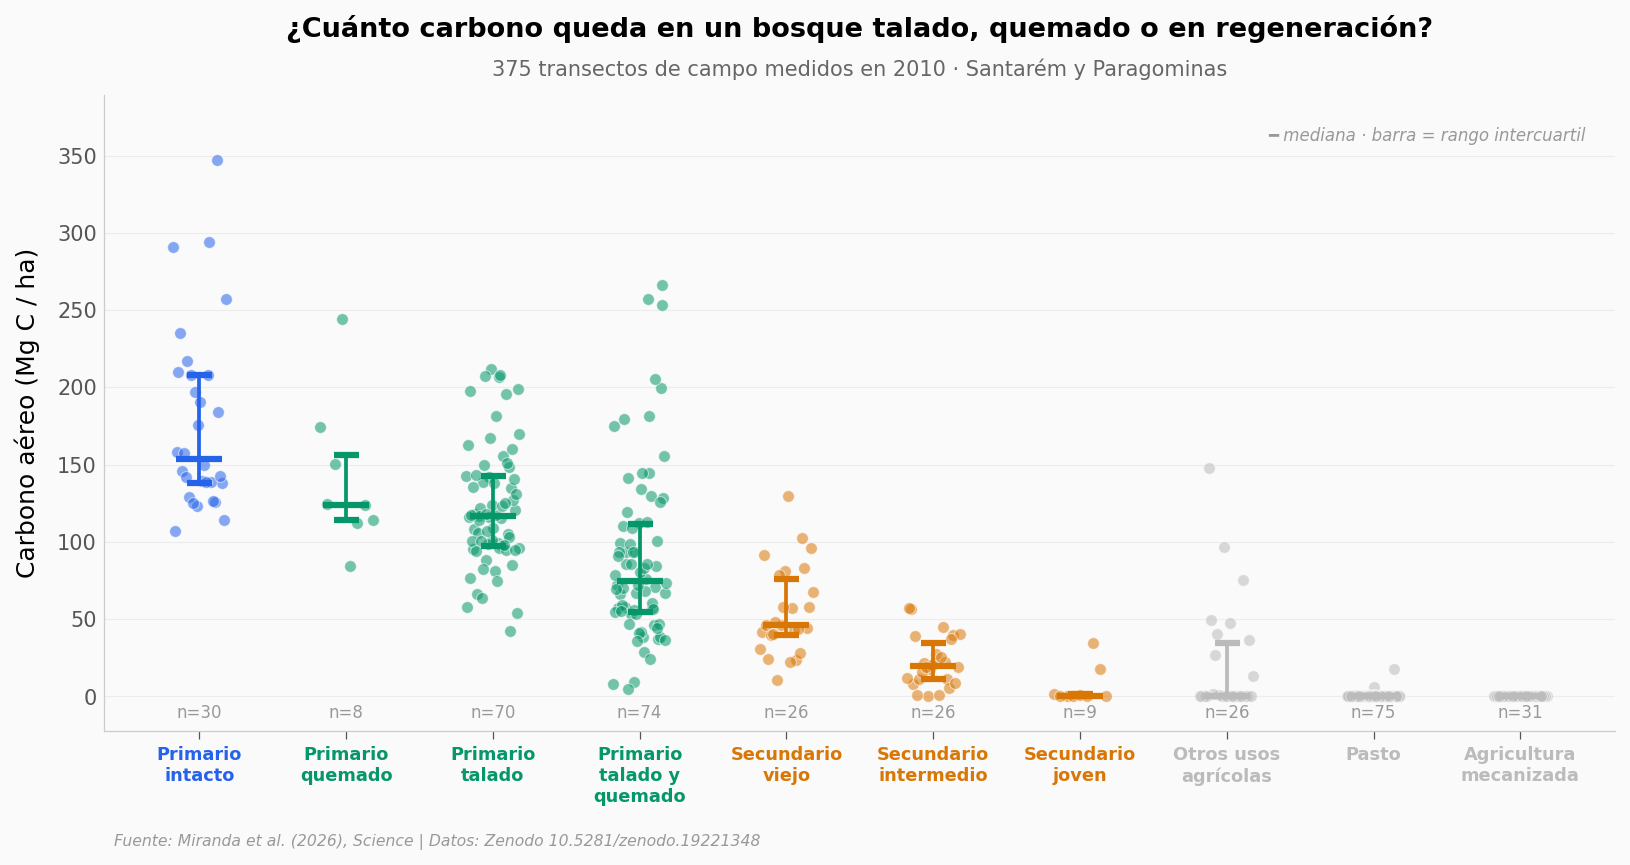

primario_intacto             n= 30  mediana  153,9 Mg C/ha  (IQR 138,3–208,0)
primario_quemado             n=  8  mediana  124,2 Mg C/ha  (IQR 113,9–156,5)
primario_talado              n= 70  mediana  116,9 Mg C/ha  (IQR 97,5–142,5)
primario_talado_y_quemado    n= 74  mediana   74,6 Mg C/ha  (IQR 54,9–111,6)
secundario_viejo             n= 26  mediana   46,3 Mg C/ha  (IQR 40,1–75,7)
secundario_intermedio        n= 26  mediana   19,9 Mg C/ha  (IQR 11,4–34,7)
secundario_joven             n=  9  mediana    0,3 Mg C/ha  (IQR 0,0–1,5)
otros_usos_agricolas         n= 26  mediana    0,0 Mg C/ha  (IQR 0,0–34,4)
pasto                        n= 75  mediana    0,0 Mg C/ha  (IQR 0,0–0,0)
agricultura_mecanizada       n= 31  mediana    0,0 Mg C/ha  (IQR 0,0–0,0)

Primario perturbado (n=152) guarda el 65,5 % del carbono mediano del intacto (n=30); secundario (n=61) el 17,9 %
Intacto vs perturbado: Mann-Whitney p = 5.9e-09 · Cohen's d = 1.31 (grupos independientes)
Intacto vs secundario: Mann-Whitney 

In [4]:
ORDEN = ['primario_intacto', 'primario_quemado', 'primario_talado', 'primario_talado_y_quemado',
         'secundario_viejo', 'secundario_intermedio', 'secundario_joven', 'otros_usos_agricolas', 'pasto', 'agricultura_mecanizada']
ETIQ = {'primario_intacto': 'Primario\nintacto', 'primario_quemado': 'Primario\nquemado', 'primario_talado': 'Primario\ntalado',
        'primario_talado_y_quemado': 'Primario\ntalado y\nquemado', 'secundario_viejo': 'Secundario\nviejo', 'secundario_intermedio': 'Secundario\nintermedio',
        'secundario_joven': 'Secundario\njoven', 'otros_usos_agricolas': 'Otros usos\nagrícolas', 'pasto': 'Pasto', 'agricultura_mecanizada': 'Agricultura\nmecanizada'}
COL_TIPO = {t: (COLOR_ADEF if t == 'primario_intacto' else COLOR_ADEG if t.startswith('primario') else COLOR_REST if t.startswith('secundario') else COLOR_GRIS) for t in ORDEN}

np.random.seed(42)
fig, ax = plt.subplots(figsize=(13, 5.5))
resumen = []
for k, t in enumerate(ORDEN):
    v = carb.loc[carb.tipo == t, 'carbono_mgc_ha'].values
    xs = np.linspace(k - 0.18, k + 0.18, len(v)); np.random.shuffle(xs)
    ax.scatter(xs, v, color=COL_TIPO[t], s=32, alpha=0.55, edgecolors='white', linewidths=0.5, zorder=5)
    q1, med, q3 = np.percentile(v, [25, 50, 75])
    ax.errorbar(k, med, yerr=[[med - q1], [q3 - med]], fmt='_', color=COL_TIPO[t], markersize=22, markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)
    ax.text(k, -14, f'n={len(v)}', ha='center', fontsize=8, color='#999999')
    resumen.append((t, len(v), med, q1, q3))
ax.set_xticks(range(len(ORDEN))); ax.set_xticklabels([ETIQ[t] for t in ORDEN], fontsize=8.5, fontweight='bold')
for tick, t in zip(ax.get_xticklabels(), ORDEN):
    tick.set_color(COL_TIPO[t])
ax.set_ylim(-22, carb.carbono_mgc_ha.max() * 1.12)
ax.set_ylabel('Carbono aéreo (Mg C / ha)')
ax.set_title('¿Cuánto carbono queda en un bosque talado, quemado o en regeneración?', fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{len(carb)} transectos de campo medidos en 2010 · Santarém y Paragominas', transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.95, '━ mediana · barra = rango intercuartil', transform=ax.transAxes, fontsize=8, color='#999999', ha='right', va='top', style='italic')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/carbono_por_tipo.png', dpi=200, bbox_inches='tight')
plt.show()

for t, n, med, q1, q3 in resumen:
    print(f'{t:28s} n={n:3d}  mediana {es(med, 1):>6} Mg C/ha  (IQR {es(q1, 1)}–{es(q3, 1)})')
intacto = carb.loc[carb.tipo == 'primario_intacto', 'carbono_mgc_ha']
pert = carb.loc[carb.tipo.isin(['primario_talado', 'primario_quemado', 'primario_talado_y_quemado']), 'carbono_mgc_ha']
sec = carb.loc[carb.tipo.str.startswith('secundario'), 'carbono_mgc_ha']
pooled = np.sqrt(((len(intacto) - 1) * intacto.std() ** 2 + (len(pert) - 1) * pert.std() ** 2) / (len(intacto) + len(pert) - 2))
d = abs(intacto.mean() - pert.mean()) / pooled
p = stats.mannwhitneyu(intacto, pert).pvalue
print(f'\nPrimario perturbado (n={len(pert)}) guarda el {es(100 * pert.median() / intacto.median(), 1)} % del carbono mediano del intacto (n={len(intacto)}); '
      f'secundario (n={len(sec)}) el {es(100 * sec.median() / intacto.median(), 1)} %')
print(f"Intacto vs perturbado: Mann-Whitney p = {p:.1e} · Cohen's d = {d:.2f} (grupos independientes)")
pooled_s = np.sqrt(((len(intacto) - 1) * intacto.std() ** 2 + (len(sec) - 1) * sec.std() ** 2) / (len(intacto) + len(sec) - 2))
d_sec = abs(intacto.mean() - sec.mean()) / pooled_s
p_sec = stats.mannwhitneyu(intacto, sec).pvalue
print(f"Intacto vs secundario: Mann-Whitney p = {p_sec:.1e} · Cohen's d = {d_sec:.2f} (n = {len(intacto)} vs {len(sec)})")
for nombre, v in [('intacto', intacto), ('perturbado', pert), ('secundario', sec)]:
    print(f"  Shapiro-Wilk {nombre}: p = {stats.shapiro(v).pvalue:.1e} → no normal, por eso Mann-Whitney y medianas")
# Nota: los porcentajes por tipo respecto al intacto
for t in ['primario_quemado', 'primario_talado', 'primario_talado_y_quemado']:
    print(f"  {t}: {es(100 * carb.loc[carb.tipo == t, 'carbono_mgc_ha'].median() / intacto.median(), 1)} % de la mediana del intacto")

## La base física del resultado

Un bosque primario intacto guarda una mediana de 153,9 Mg C por hectárea (n = 30). Talado o quemado, sigue siendo bosque, pero baja a 74,6 en el peor caso (talado y quemado, n = 74): el primario perturbado conserva el 65,5 % del carbono mediano del intacto, con un tamaño de efecto grande (Cohen's d = 1,31, Mann-Whitney p = 5,9×10⁻⁹, grupos independientes de 30 y 152 transectos). Un bosque secundario, el que crece donde se restaura, va mucho más atrás: 46,3 Mg C/ha el viejo, 19,9 el intermedio y 0,3 el joven — en conjunto, el 17,9 % del intacto (Cohen's d = 3,44, Mann-Whitney p = 1,8×10⁻¹⁴, n = 30 vs 61).

Ahí está la lógica de las curvas de arriba. Restaurar arranca desde pasto (mediana 0,0 Mg C/ha, n = 75) y tarda décadas en acercarse a un bosque viejo; evitar que talen o quemen un primario conserva de golpe lo que la perturbación se llevaría: según el tipo, el bosque perturbado guarda entre la mitad y cuatro quintos del carbono del intacto (quemado 80,7 %, talado 75,9 %, talado y quemado 48,5 % de la mediana; 65,5 % agrupando los tres). Los transectos son observacionales — no siguen el mismo bosque antes y después — así que hablamos de diferencias entre tipos, no de lo que *pasa* al talar uno concreto.

Queda una pregunta: ¿cuánto bosque tienen realmente estas 6.900 fincas? Porque de eso depende, según la curva, si a cada una le conviene proteger o restaurar.

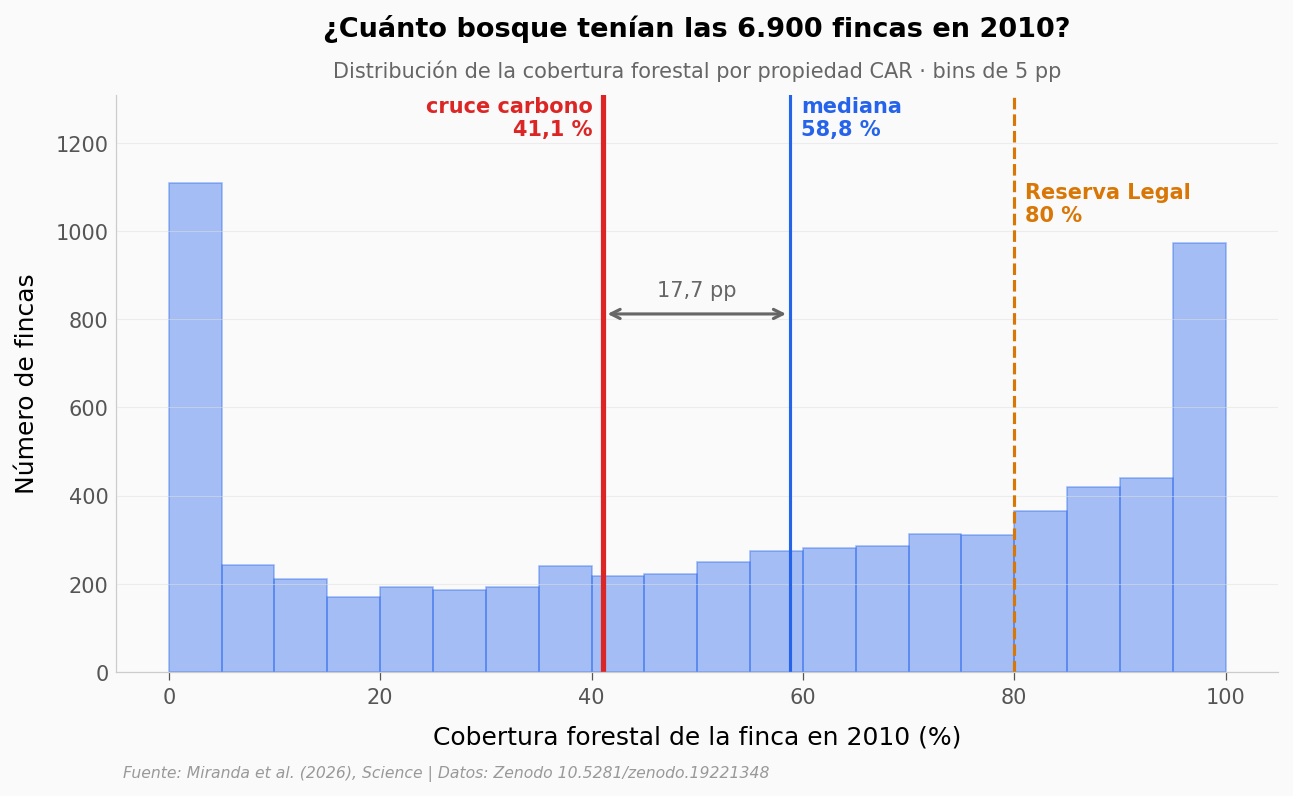

Cobertura 2010: media 53,6 % · mediana 58,8 % · IQR 19,6–86,3 % · asimetría -0.21
  sin bosque (0 %): 10,9 % · con ≥ 99,9 %: 4,6 % · registradas por encima del 100 %: 236 fincas (3,4 %)
  por debajo del cruce de carbono (41,1 %): 37,6 % de las fincas · por debajo del 50 %: 43,3 %
  por encima del 80 % (≈ con excedente sobre la Reserva Legal): 31,9 %  (paper: ~32 % con excedente)
    Paragominas: mediana 47,9 % · > 80 %: 22,7 %
    Santarem: mediana 62,2 % · > 80 %: 34,5 %


In [5]:
cov = prop.cobertura_forestal_2010_pct
# 236 fincas tienen una cobertura registrada > 100 % (píxeles de bosque sobre el polígono de la finca): van al último bin
fig, ax = plt.subplots(figsize=(10, 5))
n, b, _ = ax.hist(cov.clip(upper=100), bins=np.arange(0, 105, 5), color=COLOR_ADEF, alpha=0.4, edgecolor=COLOR_ADEF, linewidth=0.8)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)
ax.axvline(x_car, color=COLOR_ALERTA, linewidth=2.5)
ax.axvline(UMBRAL_LEGAL_PCT, color=COLOR_REST, linewidth=1.5, linestyle='--')
ax.axvline(cov.median(), color=COLOR_ADEF, linewidth=1.5)
ax.annotate('', xy=(x_car, y_max * 0.62), xytext=(cov.median(), y_max * 0.62), arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((x_car + cov.median()) / 2, y_max * 0.65, f'{es(cov.median() - x_car, 1)} pp', ha='center', fontsize=10, color='#666666')
ax.text(x_car - 1, y_max * 0.93, f'cruce carbono\n{es(x_car, 1)} %', color=COLOR_ALERTA, fontsize=10, fontweight='bold', ha='right')
ax.text(cov.median() + 1, y_max * 0.93, f'mediana\n{es(cov.median(), 1)} %', color=COLOR_ADEF, fontsize=10, fontweight='bold')
ax.text(UMBRAL_LEGAL_PCT + 1, y_max * 0.78, f'Reserva Legal\n{UMBRAL_LEGAL_PCT} %', color=COLOR_REST, fontsize=10, fontweight='bold')
ax.set_xlabel('Cobertura forestal de la finca en 2010 (%)')
ax.set_ylabel('Número de fincas')
ax.set_title('¿Cuánto bosque tenían las 6.900 fincas en 2010?', fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de la cobertura forestal por propiedad CAR · bins de 5 pp', transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cobertura_2010.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Cobertura 2010: media {es(cov.mean(), 1)} % · mediana {es(cov.median(), 1)} % · IQR {es(cov.quantile(.25), 1)}–{es(cov.quantile(.75), 1)} % · asimetría {cov.skew():.2f}')
print(f'  sin bosque (0 %): {es(100 * (cov == 0).mean(), 1)} % · con ≥ 99,9 %: {es(100 * (cov >= 99.9).mean(), 1)} % · registradas por encima del 100 %: {(cov > 100).sum()} fincas ({es(100 * (cov > 100).mean(), 1)} %)')
print(f'  por debajo del cruce de carbono ({es(x_car, 1)} %): {es(100 * (cov < x_car).mean(), 1)} % de las fincas · por debajo del 50 %: {es(100 * (cov < 50).mean(), 1)} %')
print(f'  por encima del {UMBRAL_LEGAL_PCT} % (≈ con excedente sobre la Reserva Legal): {es(100 * (cov > UMBRAL_LEGAL_PCT).mean(), 1)} %  (paper: ~32 % con excedente)')
for r, g in prop.groupby('region'):
    print(f'    {r}: mediana {es(g.cobertura_forestal_2010_pct.median(), 1)} % · > {UMBRAL_LEGAL_PCT} %: {es(100 * (g.cobertura_forestal_2010_pct > UMBRAL_LEGAL_PCT).mean(), 1)} %')

## Ni concentradas ni parejas

La distribución es dispersa: la mediana es 58,8 % pero el rango intercuartil va de 19,6 % a 86,3 %. Un 10,9 % de las fincas no tenía nada de bosque en 2010 y un 4,6 % estaba entera cubierta. El 43,3 % está por debajo del 50 % de cobertura y el 31,9 % por encima del 80 % — ese último grupo se parece al "~32 % de propiedades con excedente sobre la Reserva Legal" que cita el paper, aunque es una aproximación: el requisito real depende del tamaño de la finca y de las áreas de protección permanente, y aquí usamos un 80 % plano.

Santarém y Paragominas no son iguales: la mediana de cobertura es 62,2 % en Santarém y 47,9 % en Paragominas, y la fracción por encima del 80 % es 34,5 % frente a 22,7 %.

Lo que no podemos recomputar desde estos datos y el paper sí afirma: que combinando las tres intervenciones se revierte la pérdida (+22 % de biodiversidad y +42 % de carbono sobre 2010, frente a +12 % y +18 % solo evitando), que la restauración sigue siendo la menos costo-efectiva incluso recortando sus costos un 95 %, y que las conclusiones probablemente aplican a otras regiones tropicales. Los costos no están en el repositorio.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Evitar la perturbación aporta más biodiversidad que evitar la deforestación | ✅ | 2,28× sumando las 6.900 fincas CAR (paper: 2,45× sobre el paisaje completo; −7 % por alcance). Mismo ranking |
| Evitar la deforestación aporta más carbono que evitar la perturbación | ✅ | 1,44× (paper: 1,30×; +11 % por alcance). Mismo ranking |
| La restauración rinde alrededor de una cuarta parte de lo que rinde evitar la deforestación | ✅ | 0,26× en biodiversidad y 0,27× en carbono (paper: 0,23× y 0,24×) |
| Restaurar solo supera a evitar deforestación en fincas con menos de ~43 % (biodiversidad) y ~41 % (carbono) de cobertura | ✅ | Cruce por interpolación entre medias de bins de 5 pp: 42,7 % y 41,1 % (paper: ~43 % y ~41 % con modelo aditivo remuestreado). Con bins de 10 pp: 43,1 % y 41,0 %. Cinco de los seis bins de 5-35 % con n < 30 |
| Un primario talado o quemado conserva unos dos tercios del carbono del intacto; el secundario menos de una quinta parte | ✅ | Medianas de 375 transectos: perturbado 65,5 % del intacto, secundario 17,9 %. Intacto vs perturbado: Cohen's d = 1,31, p = 5,9×10⁻⁹ (n = 30 vs 152). Cálculo nuestro, el paper no lo reporta |
| Cerca de un tercio de las fincas tiene más bosque del que exige la ley | ⚠️ | 31,9 % con cobertura > 80 % (paper: ~32 % con excedente). Aproximación con un umbral plano; el requisito legal varía por tamaño de finca |
| Solo combinando las tres intervenciones se revierte la pérdida de biodiversidad y carbono | ⚠️ | +22 % y +42 % sobre 2010 según el paper; los escenarios combinados no están en el repositorio y no se pueden recomputar |
| Evitar es más costo-efectivo que restaurar, y el resultado se sostiene con costos de restauración un 95 % menores | ⚠️ | Cifras del paper (por R$10.000: biodiversidad 0,372 / 0,123 / 0,025; carbono 52,0 / 33,8 / 14,2 Mg C). Los costos no están en los datos abiertos |

> **Limitaciones:** (1) Los beneficios son diferencias entre escenarios modelados, no efectos observados — los autores los llaman herramientas de diagnóstico. (2) Las sumas cubren solo las 6.900 fincas CAR (2.623.360 ha), no el paisaje completo del paper (>3 millones de ha); por eso los ratios difieren entre un 7 % y un 13 %. (3) El beneficio por hectárea es sobre toda la finca y en diez años: no es comparable con la Fig 2 del paper (por píxel intervenido y por año). (4) Cinco de los seis bins de cobertura entre 5 % y 35 % tienen menos de 30 fincas (entre 15 y 28); el sexto, 20-25 %, tiene 32. (5) Los transectos son observacionales: distintos bosques, no el mismo antes y después. (6) 26 transectos con códigos de uso sin definición en el repositorio (AP, REF, FRU, SHA) van agrupados como "otros usos agrícolas" y no se interpretan. (7) El "% de fincas con beneficio de restauración > 0" incluye el efecto de borde de restaurar en fincas vecinas, así que no equivale al 18 % con déficit legal que cita el paper. (8) Los 381 transectos del paper son 375 en el CSV con dato de carbono.

## Ahora tú

1. ¿El cruce cae en el mismo sitio en Santarém que en Paragominas? Pista: cambia `REGION` en la configuración y vuelve a ejecutar la gráfica hero — o mira la celda de abajo.
2. ¿Qué pasa con el cruce si usas bins más anchos o más finos? Pista: `BIN_PP = 10` o `BIN_PP = 2` (con 2 pp, muchos bins quedan casi vacíos).
3. ¿Cómo se reparte el beneficio de restauración entre fincas pequeñas, medianas y grandes? Pista: `prop.groupby('clase_tamano')['carbono_restauracion_mgc_por_ha'].agg(['mean', lambda s: (s > 0).mean()])`.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿el cruce restauración < evitar deforestación cae en el mismo sitio en cada región?
for reg in ['Santarem', 'Paragominas']:
    sub = prop[prop.clase_tamano.isin(CLASES_CURVAS) & (prop.region == reg)].copy()
    sub['bin'] = pd.cut(sub.cobertura_forestal_2010_pct, bins, right=False, include_lowest=True)
    gb, gcar = curvas(sub, 'biodiv', '_por_ha'), curvas(sub, 'carbono', '_mgc_por_ha')
    xb, xcar = cruce(gb), cruce(gcar)
    print(f'{reg:12s} ({es(len(sub))} fincas medianas y grandes) — cruce biodiversidad: {es(xb, 1) if xb else "sin cruce"} % · carbono: {es(xcar, 1) if xcar else "sin cruce"} % · bins con n < 30: {(gcar.n < 30).sum()} de {len(gcar)}')

# Pregunta 3: restauración por clase de finca
r = prop.groupby('clase_tamano').agg(n=('id', 'size'), con_beneficio_pct=('carbono_restauracion_mgc_por_ha', lambda s: 100 * (s > 0).mean()),
                                     carbono_restor_por_ha_media=('carbono_restauracion_mgc_por_ha', 'mean'), cobertura_mediana=('cobertura_forestal_2010_pct', 'median'))
print('\n' + r.round(1).to_string())

Santarem     (242 fincas medianas y grandes) — cruce biodiversidad: 46,8 % · carbono: 42,7 % · bins con n < 30: 19 de 20
Paragominas  (790 fincas medianas y grandes) — cruce biodiversidad: 42,6 % · carbono: 41,0 % · bins con n < 30: 6 de 20

                 n  con_beneficio_pct  carbono_restor_por_ha_media  cobertura_mediana
clase_tamano                                                                         
grande         600               55.7                         22.5               69.9
mediana        432               57.6                         48.6               56.2
pequena       5868               26.8                          7.8               57.5


## Créditos

**Paper:** Miranda, D. L. C. et al. (2026). Protecting tropical forests is more cost-effective for biodiversity and climate than restoration. *Science* 393(6817). DOI: [10.1126/science.adx9928](https://doi.org/10.1126/science.adx9928) — acceso abierto.

**Datos:** repositorio de código y datos de los autores en Zenodo ([10.5281/zenodo.19221348](https://doi.org/10.5281/zenodo.19221348), v1.0.1). Los tres CSV de este notebook son `car_benefits.csv`, `carbon.csv` y `species_summary.csv` con columnas renombradas a español; los códigos de tipo de bosque (RAS) se tradujeron según el README del repositorio.

**Notebook:** [Ciencia a Mordiscos — Lab](https://github.com/Ciencia-a-Mordiscos/lab) · licencia MIT para el código; los datos conservan la licencia del repositorio original.

## Fuentes

**Paper**: [Protecting tropical forests is more cost-effective for biodiversity and climate than restoration](https://doi.org/10.1126/science.adx9928)  
*Science, 2026-09-17 · acceso abierto*

**Datos**: [Code for "Protecting tropical forests is more cost-effective for biodiversity and climate than restoration" (v1.0.1)](https://doi.org/10.5281/zenodo.19221348)  
*Zenodo · car_benefits.csv, carbon.csv, species_summary.csv*

*32 afirmaciones del notebook verificadas contra estas fuentes*